In [1]:
import os
import zipfile
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from scipy import ndimage
import nibabel as nib

# Load CT Scan Data

In [2]:
# Download CT scan data (normal and abnormal)
!wget -q https://github.com/hasibzunair/3D-image-classification-tutorial/releases/download/v0.2/CT-0.zip
!wget -q https://github.com/hasibzunair/3D-image-classification-tutorial/releases/download/v0.2/CT-23.zip

os.makedirs("MosMedData", exist_ok=True)
with zipfile.ZipFile("CT-0.zip", "r") as z:
    z.extractall("./MosMedData/")
with zipfile.ZipFile("CT-23.zip", "r") as z:
    z.extractall("./MosMedData/")

# Preprocessing

In [3]:
# Preprocessing utilities
def read_nifti_file(filepath):
    scan = nib.load(filepath)
    return scan.get_fdata()

def normalize(volume):
    volume = np.clip(volume, -1000, 400)
    volume = (volume + 1000) / 1400
    return volume.astype("float32")

def resize_volume(img):
    """Resize the volume to the desired shape."""
    desired_depth = 64  # Desired depth of the volume
    desired_width = 128  # Desired width of the volume
    desired_height = 128  # Desired height of the volume
    # Get the current shape of the volume
    current_depth, current_width, current_height = img.shape
    # Calculate the zoom factors for each dimension
    depth_factor = desired_depth / current_depth
    width_factor = desired_width / current_width
    height_factor = desired_height / current_height
    # Rotate and zoom the image to the desired shape
    img = ndimage.rotate(img, 90, reshape=False)
    #order=1 for trilinear interpolation to preserve data when zooming
    img = ndimage.zoom(img, (depth_factor, width_factor, height_factor), order=1)
    return img

def process_scan(path):
    volume = read_nifti_file(path)
    volume = normalize(volume)
    volume = resize_volume(volume)
    return volume

# Load Files

In [4]:
# Load file paths
normal_paths = ["MosMedData/CT-0/" + fname for fname in os.listdir("MosMedData/CT-0")]
abnormal_paths = ["MosMedData/CT-23/" + fname for fname in os.listdir("MosMedData/CT-23")]

# Process Samples

In [5]:
# Process limited samples
normal_scans = [process_scan(path) for path in normal_paths[:20]]
abnormal_scans = [process_scan(path) for path in abnormal_paths[:20]]

# Check shapes and print if different
for i, scan in enumerate(normal_scans):
    print(f"Normal scan {i} shape: {scan.shape}")
for i, scan in enumerate(abnormal_scans):
    print(f"Abnormal scan {i} shape: {scan.shape}")

# Ensure all scans have the same shape before stacking
shapes = [scan.shape for scan in normal_scans + abnormal_scans]
if len(set(shapes)) != 1:  # Check if all shapes are the same
    # If not, find the most common shape and resize all scans to that shape
    most_common_shape = Counter(shapes).most_common(1)[0][0]

    normal_scans = [np.resize(scan, most_common_shape) for scan in normal_scans]
    abnormal_scans = [np.resize(scan, most_common_shape) for scan in abnormal_scans]

Normal scan 0 shape: (64, 128, 128)
Normal scan 1 shape: (64, 128, 128)
Normal scan 2 shape: (64, 128, 128)
Normal scan 3 shape: (64, 128, 128)
Normal scan 4 shape: (64, 128, 128)
Normal scan 5 shape: (64, 128, 128)
Normal scan 6 shape: (64, 128, 128)
Normal scan 7 shape: (64, 128, 128)
Normal scan 8 shape: (64, 128, 128)
Normal scan 9 shape: (64, 128, 128)
Normal scan 10 shape: (64, 128, 128)
Normal scan 11 shape: (64, 128, 128)
Normal scan 12 shape: (64, 128, 128)
Normal scan 13 shape: (64, 128, 128)
Normal scan 14 shape: (64, 128, 128)
Normal scan 15 shape: (64, 128, 128)
Normal scan 16 shape: (64, 128, 128)
Normal scan 17 shape: (64, 128, 128)
Normal scan 18 shape: (64, 128, 128)
Normal scan 19 shape: (64, 128, 128)
Abnormal scan 0 shape: (64, 128, 128)
Abnormal scan 1 shape: (64, 128, 128)
Abnormal scan 2 shape: (64, 128, 128)
Abnormal scan 3 shape: (64, 128, 128)
Abnormal scan 4 shape: (64, 128, 128)
Abnormal scan 5 shape: (64, 128, 128)
Abnormal scan 6 shape: (64, 128, 128)
Abno

In [7]:
# Create labels for normal and abnormal scans
normal_labels = np.zeros(len(normal_scans))  # Label 0 for normal scans
abnormal_labels = np.ones(len(abnormal_scans)) # Label 1 for abnormal scans

# Now stack the scans, as they should all have the same shape
x_train = np.concatenate([np.stack(normal_scans[:14]), np.stack(abnormal_scans[:14])])
y_train = np.concatenate([normal_labels[:14], abnormal_labels[:14]])
x_val = np.concatenate([np.stack(normal_scans[14:]), np.stack(abnormal_scans[14:])])
y_val = np.concatenate([normal_labels[14:], abnormal_labels[14:]])

In [8]:
# Split to train and val
# Convert lists of 3D scans to 4D NumPy arrays before concatenation
x_train = np.concatenate([np.stack(normal_scans[:14]), np.stack(abnormal_scans[:14])])
y_train = np.concatenate([normal_labels[:14], abnormal_labels[:14]])
x_val = np.concatenate([np.stack(normal_scans[14:]), np.stack(abnormal_scans[14:])])
y_val = np.concatenate([normal_labels[14:], abnormal_labels[14:]])

In [9]:
# Add channel dimension
def add_channel(x, y):
    # Reshape to match expected input shape
    x = tf.transpose(x, perm=[1, 2, 0])  # Transpose to (128, 128, 64)
    x = tf.expand_dims(x, -1)           # Add channel dimension to (128, 128, 64, 1)
    return x, y

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).map(add_channel).batch(2)
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val)).map(add_channel).batch(2)

# Model

In [10]:
# Define 3D CNN
inputs = keras.Input((128, 128, 64, 1))
x = layers.Conv3D(32, 3, activation='relu')(inputs)
x = layers.MaxPooling3D()(x)
x = layers.BatchNormalization()(x)
x = layers.Conv3D(64, 3, activation='relu')(x)
x = layers.MaxPooling3D()(x)
x = layers.BatchNormalization()(x)
x = layers.Conv3D(128, 3, activation='relu')(x)
x = layers.GlobalAveragePooling3D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 230ms/step - accuracy: 0.8268 - loss: 1.2546 - val_accuracy: 0.5000 - val_loss: 0.6953
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.3670 - loss: 1.4799 - val_accuracy: 0.5000 - val_loss: 0.8324
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.3142 - loss: 2.1356 - val_accuracy: 0.5000 - val_loss: 0.7523
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.1772 - loss: 2.0385 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.3278 - loss: 0.9989 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.0422 - loss: 1.8855 - val_accuracy: 0.5000 - val_loss: 0.6877
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.2455 - loss: 0.9439 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.4310 - loss: 0.7483 - val_accuracy: 0.4167 

# Training Curves

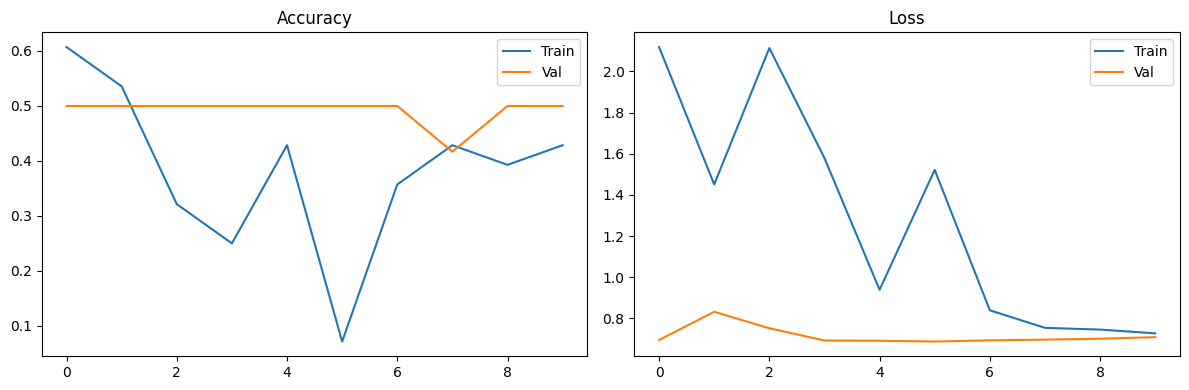

In [11]:
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train', 'Val'])
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train', 'Val'])
plt.tight_layout()
plt.show()

# Prediction

In [15]:
# Predict on one volume
sample = x_val[0]  # Get the first volume from x_val
# Reshape to match expected input shape
sample = tf.transpose(sample, perm=[1, 2, 0])  # Transpose to (128, 128, 64)
sample = tf.expand_dims(sample, axis=0)  # Add batch dimension
sample = tf.expand_dims(sample, axis=-1)  # Add channel dimension

# Convert the sample to a TensorFlow tensor if necessary
sample = tf.convert_to_tensor(sample, dtype=tf.float32)

pred = model.predict(sample)[0][0]
print(f"Confidence abnormal: {pred:.2f}, normal: {1 - pred:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step
Confidence abnormal: 0.45, normal: 0.55


# Visualization

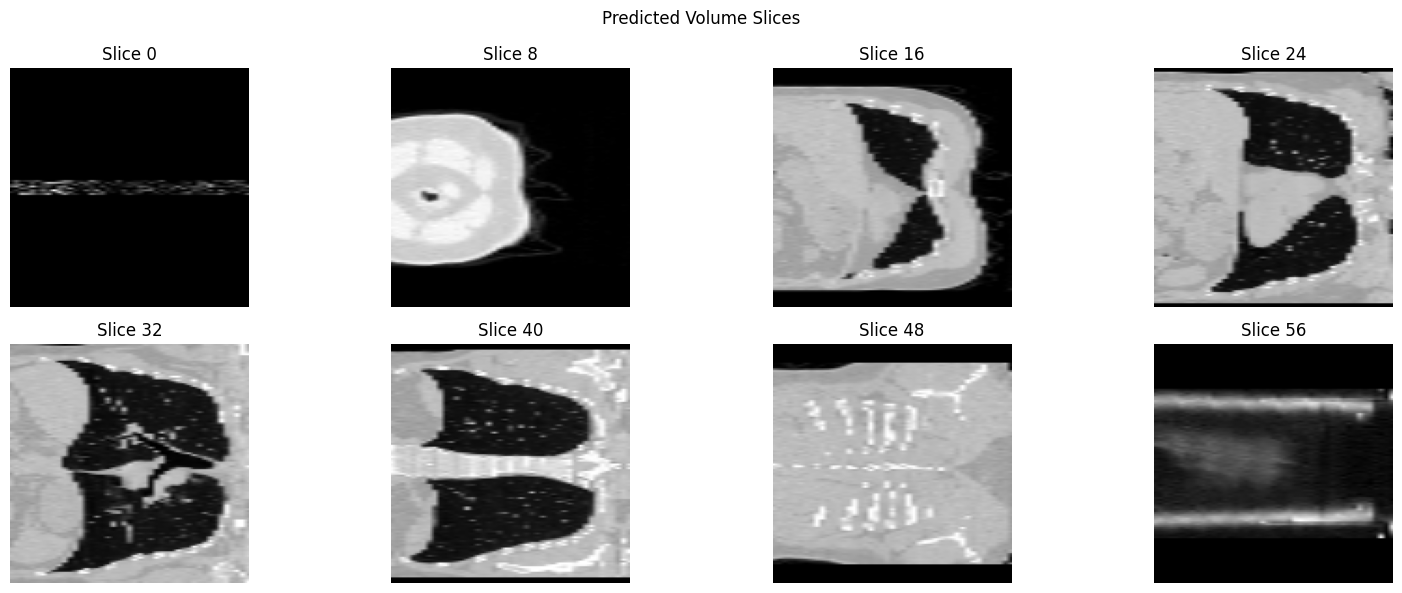

In [16]:
# Visualize slices of predicted volume
volume = tf.squeeze(sample).numpy()  # shape: (128, 128, 64)
num_slices = volume.shape[-1]

plt.figure(figsize=(16, 6))
for i in range(0, num_slices, 8):  # Show 8 slices (every 8th)
    ax = plt.subplot(2, 4, i//8 + 1)
    plt.imshow(volume[:, :, i], cmap="gray")
    plt.title(f"Slice {i}")
    plt.axis("off")
plt.suptitle("Predicted Volume Slices")
plt.tight_layout()
plt.show()

# CT Scan Visualization

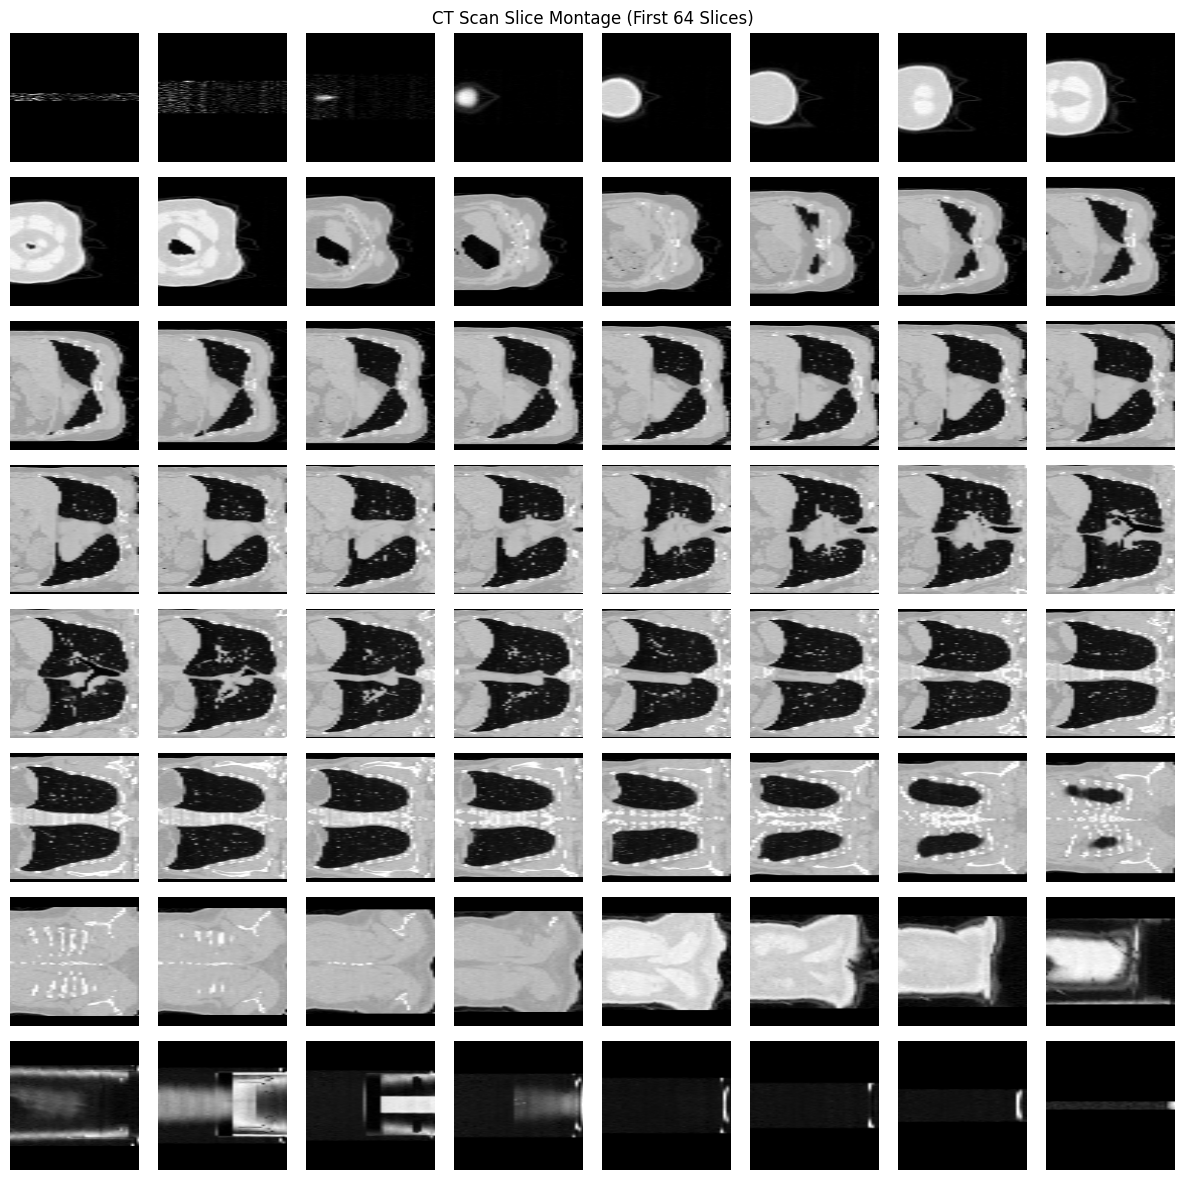

In [17]:
# Visualize montage of slices (first 64)
def plot_montage(volume):
    fig, axes = plt.subplots(8, 8, figsize=(12, 12))
    slice_idx = 0
    for i in range(8):
        for j in range(8):
            if slice_idx < volume.shape[-1]:
                axes[i, j].imshow(volume[:, :, slice_idx], cmap="gray")
                axes[i, j].axis("off")
                slice_idx += 1
    plt.suptitle("CT Scan Slice Montage (First 64 Slices)")
    plt.tight_layout()
    plt.show()

plot_montage(volume)